In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIG_DIR = BASE_DIR / "figures" / "part1"

FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
spot = pd.read_csv(PROCESSED_DIR / "audusd_spot_processed.csv", parse_dates=["Date"])
cpi = pd.read_csv(PROCESSED_DIR / "audusd_cpi_processed.csv", parse_dates=["Date"])
strategy_data = pd.read_csv(PROCESSED_DIR / "audusd_strategy_data.csv", parse_dates=["Date"])

print("spot:", spot.shape)
print("cpi:", cpi.shape)
print("strategy_data:", strategy_data.shape)

strategy_data.head()

spot: (181, 3)
cpi: (180, 6)
strategy_data: (179, 15)


,Date,spot,fx_return,rate_au,rate_us,cpi_au,cpi_us,infl_au,infl_us,infl_diff,rate_diff,signal,carry_component,fx_component,strategy_return
0,2009-02-28,0.642219,0.005827,3.35,0.16,64.206667,212.193,0.000363,0.004961,-0.004597,3.19,1,0.002658,0.005827,0.008485
1,2009-03-31,0.691802,0.074370,3.25,0.17,64.230000,212.709,0.000363,0.002429,-0.002065,3.08,1,0.002567,0.074370,0.076937
2,2009-04-30,0.726691,0.049202,3.06,0.04,64.336667,213.240,0.001659,0.002493,-0.000834,3.02,1,0.002517,0.049202,0.051719
3,2009-05-31,0.801025,0.097391,3.00,0.14,64.443333,213.856,0.001657,0.002885,-0.001228,2.86,1,0.002383,0.097391,0.099774
4,2009-06-30,0.806192,0.006429,3.00,0.17,64.550000,215.693,0.001654,0.008553,-0.006899,2.83,1,0.002358,0.006429,0.008787


In [4]:
df = strategy_data[[
    "Date",
    "spot",
    "fx_return",
    "rate_au",
    "rate_us",
    "infl_au",
    "infl_us",
    "infl_diff"
]].copy()

df["rate_diff"] = (df["rate_au"] - df["rate_us"]) / 100 / 12

df.head(12)

,Date,spot,fx_return,rate_au,rate_us,infl_au,infl_us,infl_diff,rate_diff
0,2009-02-28,0.642219,0.005827,3.35,0.16,0.000363,0.004961,-0.004597,0.002658
1,2009-03-31,0.691802,0.074370,3.25,0.17,0.000363,0.002429,-0.002065,0.002567
2,2009-04-30,0.726691,0.049202,3.06,0.04,0.001659,0.002493,-0.000834,0.002517
3,2009-05-31,0.801025,0.097391,3.00,0.14,0.001657,0.002885,-0.001228,0.002383
4,2009-06-30,0.806192,0.006429,3.00,0.17,0.001654,0.008553,-0.006899,0.002358
5,2009-07-31,0.835631,0.035866,3.00,0.14,0.003145,-0.001587,0.004732,0.002383
6,2009-08-31,0.842886,0.008644,3.00,0.11,0.003135,0.002240,0.000895,0.002408
7,2009-09-30,0.883783,0.047379,3.00,0.06,0.003125,0.000625,0.002500,0.002450
8,2009-10-31,0.900982,0.019274,3.21,0.01,0.001789,0.000963,0.000826,0.002667
9,2009-11-30,0.917600,0.018276,3.48,0.08,0.001786,0.000708,0.001078,0.002833


In [5]:
df["actual_fx_change"] = df["fx_return"]
df["uip_implied_change"] = df["rate_diff"]
df["ppp_implied_change"] = df["infl_diff"]

df[["Date", "actual_fx_change", "uip_implied_change", "ppp_implied_change"]].head(12)

,Date,actual_fx_change,uip_implied_change,ppp_implied_change
0,2009-02-28,0.005827,0.002658,-0.004597
1,2009-03-31,0.074370,0.002567,-0.002065
2,2009-04-30,0.049202,0.002517,-0.000834
3,2009-05-31,0.097391,0.002383,-0.001228
4,2009-06-30,0.006429,0.002358,-0.006899
5,2009-07-31,0.035866,0.002383,0.004732
6,2009-08-31,0.008644,0.002408,0.000895
7,2009-09-30,0.047379,0.002450,0.002500
8,2009-10-31,0.019274,0.002667,0.000826
9,2009-11-30,0.018276,0.002833,0.001078


In [6]:
part1 = df.dropna(subset=[
    "actual_fx_change",
    "uip_implied_change",
    "ppp_implied_change"
]).copy()

print(part1.shape)
part1.head()

(179, 12)


,Date,spot,fx_return,rate_au,rate_us,infl_au,infl_us,infl_diff,rate_diff,actual_fx_change,uip_implied_change,ppp_implied_change
0,2009-02-28,0.642219,0.005827,3.35,0.16,0.000363,0.004961,-0.004597,0.002658,0.005827,0.002658,-0.004597
1,2009-03-31,0.691802,0.074370,3.25,0.17,0.000363,0.002429,-0.002065,0.002567,0.074370,0.002567,-0.002065
2,2009-04-30,0.726691,0.049202,3.06,0.04,0.001659,0.002493,-0.000834,0.002517,0.049202,0.002517,-0.000834
3,2009-05-31,0.801025,0.097391,3.00,0.14,0.001657,0.002885,-0.001228,0.002383,0.097391,0.002383,-0.001228
4,2009-06-30,0.806192,0.006429,3.00,0.17,0.001654,0.008553,-0.006899,0.002358,0.006429,0.002358,-0.006899


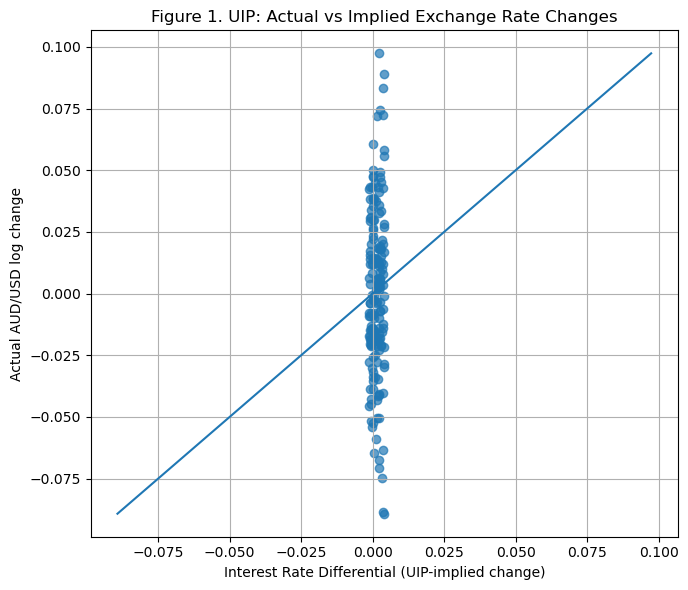

In [7]:
plt.figure(figsize=(7, 6))
plt.scatter(part1["uip_implied_change"], part1["actual_fx_change"], alpha=0.7)

xmin = min(part1["uip_implied_change"].min(), part1["actual_fx_change"].min())
xmax = max(part1["uip_implied_change"].max(), part1["actual_fx_change"].max())
plt.plot([xmin, xmax], [xmin, xmax])

plt.title("Figure 1. UIP: Actual vs Implied Exchange Rate Changes")
plt.xlabel("Interest Rate Differential (UIP-implied change)")
plt.ylabel("Actual AUD/USD log change")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure1_uip_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

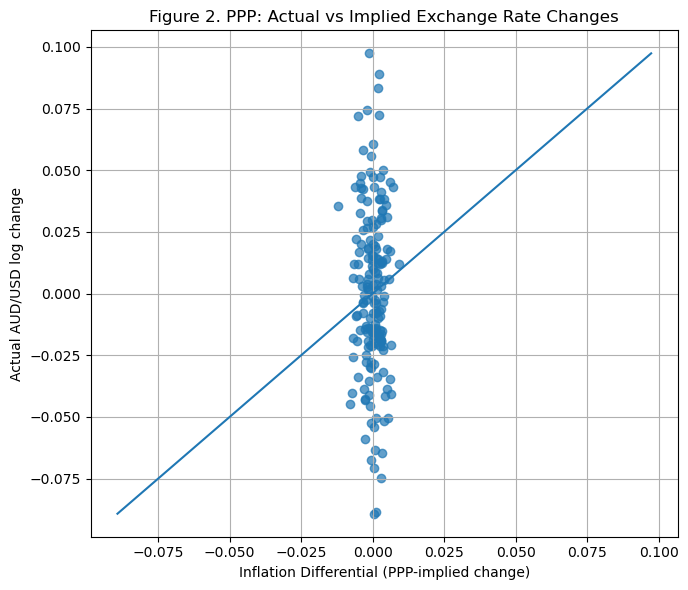

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(part1["ppp_implied_change"], part1["actual_fx_change"], alpha=0.7)

xmin = min(part1["ppp_implied_change"].min(), part1["actual_fx_change"].min())
xmax = max(part1["ppp_implied_change"].max(), part1["actual_fx_change"].max())
plt.plot([xmin, xmax], [xmin, xmax])

plt.title("Figure 2. PPP: Actual vs Implied Exchange Rate Changes")
plt.xlabel("Inflation Differential (PPP-implied change)")
plt.ylabel("Actual AUD/USD log change")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure2_ppp_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

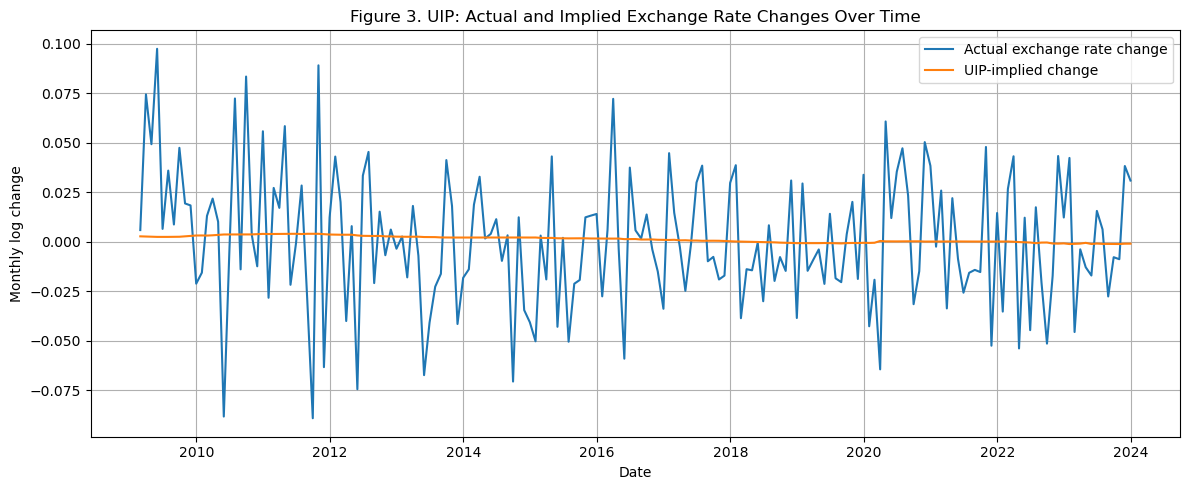

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(part1["Date"], part1["actual_fx_change"], label="Actual exchange rate change")
plt.plot(part1["Date"], part1["uip_implied_change"], label="UIP-implied change")

plt.title("Figure 3. UIP: Actual and Implied Exchange Rate Changes Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly log change")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure3_uip_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

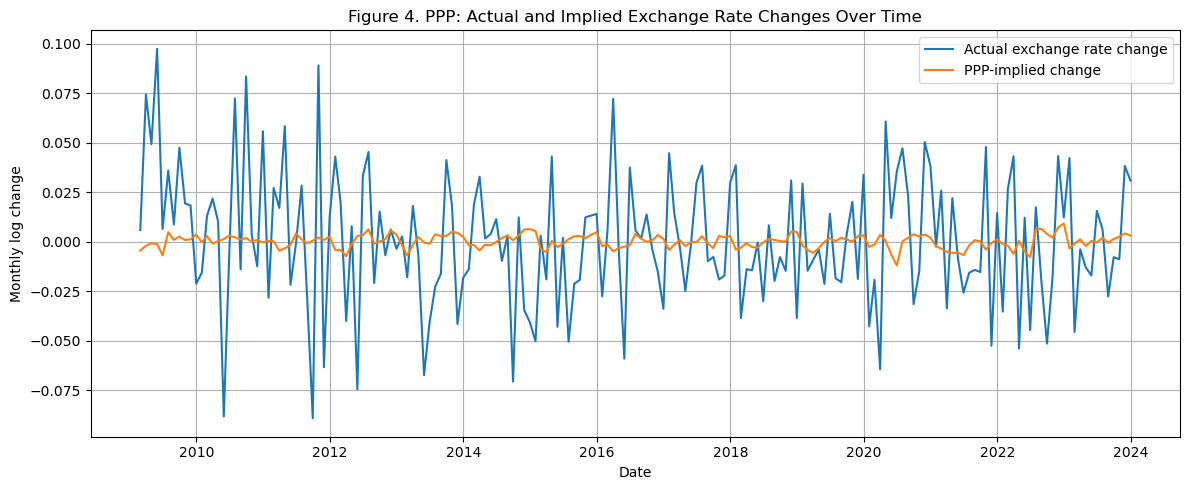

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(part1["Date"], part1["actual_fx_change"], label="Actual exchange rate change")
plt.plot(part1["Date"], part1["ppp_implied_change"], label="PPP-implied change")

plt.title("Figure 4. PPP: Actual and Implied Exchange Rate Changes Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly log change")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure4_ppp_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

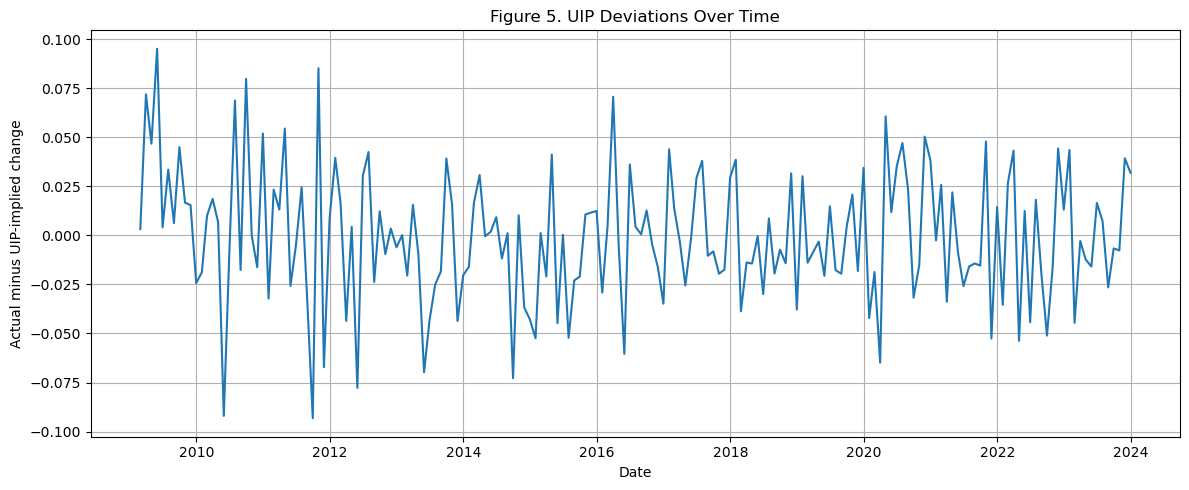

In [11]:
part1["uip_deviation"] = part1["actual_fx_change"] - part1["uip_implied_change"]

plt.figure(figsize=(12, 5))
plt.plot(part1["Date"], part1["uip_deviation"])

plt.title("Figure 5. UIP Deviations Over Time")
plt.xlabel("Date")
plt.ylabel("Actual minus UIP-implied change")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure5_uip_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

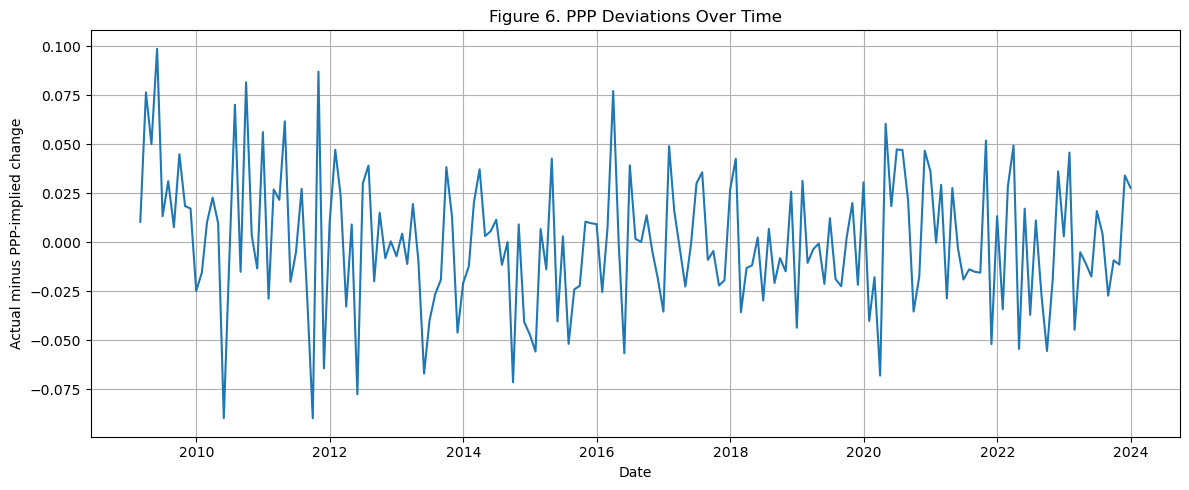

In [12]:
part1["ppp_deviation"] = part1["actual_fx_change"] - part1["ppp_implied_change"]

plt.figure(figsize=(12, 5))
plt.plot(part1["Date"], part1["ppp_deviation"])

plt.title("Figure 6. PPP Deviations Over Time")
plt.xlabel("Date")
plt.ylabel("Actual minus PPP-implied change")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure6_ppp_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
summary_part1 = pd.DataFrame({
    "metric": [
        "Mean actual FX change",
        "Mean UIP-implied change",
        "Mean PPP-implied change",
        "Std actual FX change",
        "Std UIP-implied change",
        "Std PPP-implied change"
    ],
    "value": [
        part1["actual_fx_change"].mean(),
        part1["uip_implied_change"].mean(),
        part1["ppp_implied_change"].mean(),
        part1["actual_fx_change"].std(),
        part1["uip_implied_change"].std(),
        part1["ppp_implied_change"].std()
    ]
})

summary_part1

,metric,value
0,Mean actual FX change,0.000373
1,Mean UIP-implied change,0.001206
2,Mean PPP-implied change,0.000076
3,Std actual FX change,0.033698
4,Std UIP-implied change,0.001596
5,Std PPP-implied change,0.003350
